# Validate model synthesis by comparing to pytorch

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

import math
import numpy as np

import torch


import importlib
import sys

sys.path.append('../')
sys.path.append('../../ai8x-training')

import parse_sampleoutput
import ai8x


# Read sample npy file and run inference with pytorch

(3, 88, 88)
int64
[np.int64(-128), np.int64(127)]
[65 57 54]


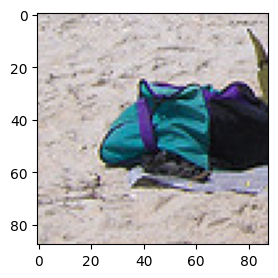

In [2]:
sample_input_file = '/home/cyril/git/giga-sam/max78000/synthesis/samples/sample_minimalsam_dataset_88_1.npy'
sample_input = np.load(sample_input_file)

print(sample_input.shape)
print(sample_input.dtype)
print([sample_input.min(), sample_input.max()])
print(sample_input[:, 0, 0])

sample_input_rgb = sample_input.transpose([1, 2, 0]).astype(np.uint8) + 128
plt.figure(figsize=(3, 3))
plt.imshow(sample_input_rgb)

In [3]:
model_input = torch.FloatTensor(sample_input).unsqueeze(0)

print(model_input.shape)
print(model_input.dtype)
print(model_input.min(), model_input.max())
print(model_input[0, :, 0, 0])

torch.Size([1, 3, 88, 88])
torch.float32
tensor(-128.) tensor(127.)
tensor([65., 57., 54.])


# Create Model

In [4]:
###################################################################################################
#
# Model definition for ai8x-training
# Image segmentation network
# Cyril Scherrer, 2025
#
###################################################################################################

"""
UNet network for MAX7800X
"""
import torch
from torch import nn

import ai8x

class MinimalSam(nn.Module):
    """
    Large size UNet model. This model also enables the use of folded data.
    """
    def __init__(
            self,
            num_classes=2,
            num_channels=3,
            dimensions=(88, 88),  # pylint: disable=unused-argument
            bias=True,
            **kwargs
    ):
        super().__init__()

        self.enc1 = ai8x.FusedConv2dBNReLU(num_channels, 8, 3, stride=1, padding=1,
                                           bias=bias, batchnorm='NoAffine', **kwargs)
        self.enc2 = ai8x.FusedMaxPoolConv2dBNReLU(8, 28, 3, stride=1, padding=1,
                                                  bias=bias, batchnorm='NoAffine', **kwargs)
        self.enc3 = ai8x.FusedMaxPoolConv2dBNReLU(28, 56, 3, stride=1, padding=1,
                                                  bias=bias, batchnorm='NoAffine', **kwargs)

        self.bneck0 = ai8x.FusedMaxPoolConv2dBNReLU(56, 56, 3, stride=1, padding=1,
                                                   bias=bias, batchnorm='NoAffine', **kwargs)
        self.bneck1 = ai8x.FusedConv2dBNReLU(56, 56, 3, stride=1, padding=1,
                                                    bias=bias, batchnorm='NoAffine', **kwargs)
        self.bneck2 = ai8x.FusedConv2dBNReLU(56, 56, 3, stride=1, padding=1,
                                                    bias=bias, batchnorm='NoAffine', **kwargs)
        self.bneck3 = ai8x.FusedConv2dBNReLU(56, 56, 3, stride=1, padding=1,
                                                    bias=bias, batchnorm='NoAffine', **kwargs)
        self.bneck4 = ai8x.FusedConv2dBNReLU(56, 56, 3, stride=1, padding=1,
                                                    bias=bias, batchnorm='NoAffine', **kwargs)
        self.bneck5 = ai8x.FusedConv2dBNReLU(56, 56, 3, stride=1, padding=1,
                                                    bias=bias, batchnorm='NoAffine', **kwargs)
        self.bneck6 = ai8x.FusedConv2dBNReLU(56, 56, 3, stride=1, padding=1,
                                                    bias=bias, batchnorm='NoAffine', **kwargs)

        self.upconv3 = ai8x.ConvTranspose2d(56, 56, 3, stride=2, padding=1)
        self.dec3 = ai8x.FusedConv2dBNReLU(112, 56, 3, stride=1, padding=1,
                                           bias=bias, batchnorm='NoAffine', **kwargs)

        self.upconv2 = ai8x.ConvTranspose2d(56, 28, 3, stride=2, padding=1)
        self.dec2 = ai8x.FusedConv2dBNReLU(56, 28, 3, stride=1, padding=1,
                                           bias=bias, batchnorm='NoAffine', **kwargs)

        self.upconv1 = ai8x.ConvTranspose2d(28, 8, 3, stride=2, padding=1)
        self.dec1 = ai8x.FusedConv2dBNReLU(16, 48, 3, stride=1, padding=1,
                                           bias=bias, batchnorm='NoAffine', **kwargs)

        self.dec0 = ai8x.FusedConv2dBNReLU(48, 64, 3, stride=1, padding=1,
                                           bias=bias, batchnorm='NoAffine', **kwargs)
        
        self.conv0 = ai8x.FusedConv2dBNReLU(64, 16, 3, stride=1, padding=1,
                                           bias=bias, batchnorm='NoAffine', **kwargs)
        self.conv1 = ai8x.FusedConv2dBN(16, num_classes, 1, stride=1, padding=0,
                                       bias=bias, batchnorm='NoAffine', **kwargs)

    def forward(self, x):  # pylint: disable=arguments-differ
        """Forward prop"""
        # Run CNN
        enc1 = self.enc1(x)                    # 8x(dim1)x(dim2)
        enc2 = self.enc2(enc1)                 # 28x(dim1/2)x(dim2/2)
        enc3 = self.enc3(enc2)                 # 56x(dim1/4)x(dim2/4)

        bneck0 = self.bneck0(enc3)          # 56x(dim1/8)x(dim2/8)
        bneck1 = self.bneck1(bneck0)          
        bneck2 = self.bneck2(bneck1)   
        bneck3 = self.bneck3(bneck2)       
        bneck4 = self.bneck4(bneck3)     
        bneck5 = self.bneck5(bneck4)           
        bneck6 = self.bneck6(bneck5)           
      
        dec3 = self.upconv3(bneck6)        # 56x(dim1/4)x(dim2/4)
        dec3 = torch.cat((dec3, enc3), dim=1)  # 112x(dim1/4)x(dim2/4)
        dec3 = self.dec3(dec3)                 # 56x(dim1/4)x(dim2/4)
        dec2 = self.upconv2(dec3)              # 28x(dim1/2)x(dim2/2)
        dec2 = torch.cat((dec2, enc2), dim=1)  # 56x(dim1/2)x(dim2/2)
        dec2 = self.dec2(dec2)                 # 28x(dim1/2)x(dim2/2)
        dec1 = self.upconv1(dec2)              # 8x(dim1)x(dim2)
        dec1 = torch.cat((dec1, enc1), dim=1)  # 16x(dim1)x(dim2)
        dec1 = self.dec1(dec1)                 # 48x(dim1)x(dim2)

        dec0 = self.dec0(dec1)                 # 32x(dim1)x(dim2)
        dec0 = self.conv0(dec0)
        dec0 = self.conv1(dec0)                 # num_final_channelsx(dim1)x(dim2)

        return dec0
    
def minimalsam(pretrained=False, **kwargs):
    """
    Constructs a unet model for image segmentation.
    """
    assert not pretrained
    return MinimalSam(**kwargs)
    
models = [
    {
        'name': 'minimalsam',
        'min_input': 1,
        'dim': 2,
    },
]

In [5]:
device = "cpu"
# qat_yaml_file_used_in_training = '../../ai8x-training/policies/qat_policy_minimalsam.yaml'
# qat_policy = parse_qat_yaml.parse(qat_yaml_file_used_in_training)
qat_policy = {'start_epoch': 1, 'weight_bits': 8}

checkpoint_path = '/home/cyril/git/giga-sam/outputs/5_1_final/epoch19_qat_q8.tar'

ai8x.set_device(device=85, simulate=True, round_avg=True)

model = MinimalSam().to(device)

# Fuse the BN parameters into conv layers before Quantization Aware Training (QAT)
ai8x.fuse_bn_layers(model)

# Switch model from unquantized to quantized for QAT
ai8x.initiate_qat(model, qat_policy)

checkpoint = torch.load(checkpoint_path)
model.load_state_dict(checkpoint['state_dict'])

ai8x.update_model(model)
model = model.to(device)

Configuring device: MAX78000, simulate=True.


In [6]:
num_weights = 0
num_bias = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        if name.endswith('weight'):
            num_weights += np.prod(param.size())
        elif name.endswith('bias'):
            num_bias += np.prod(param.size())


print(f'Number of Model Weights: {num_weights}')
print(f'Number of Model Bias: {num_bias}\n')

Number of Model Weights: 372632
Number of Model Bias: 790



In [14]:
model.eval()
with torch.no_grad():
    image = model_input.to(device)
    preds = model(image).squeeze(0)
    
    print(preds.shape)
    print(preds.dtype)
    print([preds.min(), preds.max()])
    print(preds[0][0][0], preds[1][0][0])

torch.Size([2, 88, 88])
torch.float32
[tensor(-512.), tensor(508.)]
tensor(304.) tensor(-312.)


probabilities: tensor(0.)
probabilities: tensor(1.)
mask: tensor(1)


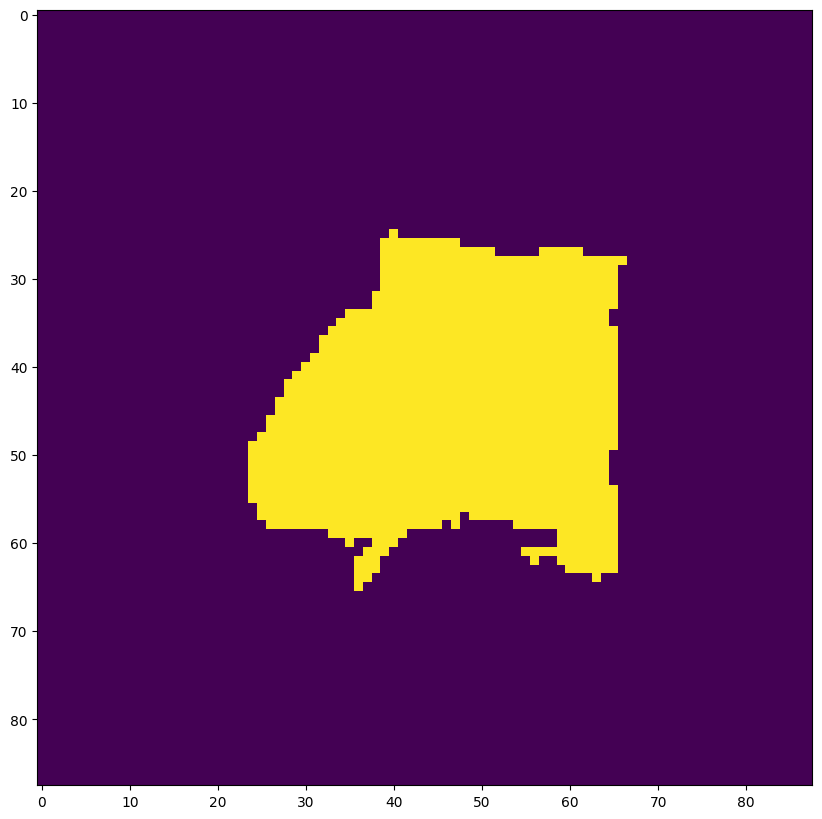

In [8]:
fig = plt.figure(figsize=(10,24))

probabilities = torch.softmax(preds, dim=0)
print("probabilities:", probabilities[0][48][48])
print("probabilities:", probabilities[1][48][48])

# print("probabilities.shape()", probabilities.shape)
# print("probabilities:", probabilities)
pred_mask = torch.argmax(probabilities, dim=0)
print("mask:", pred_mask[48][48])
# print("pred_mask.shape", pred_mask.shape)
# print("pred_mask", pred_mask)

plt.imshow(pred_mask)

# Compare to generated sampleoutput.h

1
0x50400000 7744
dict_keys(['0x50400000'])
['0x0000b24c', '0x0000a756', '0x0000a658', '0x0000a45a', '0x00009f5e', '0x00009d60', '0x00009c61', '0x00009d60', '0x00009a63', '0x00009865', '0x00009567', '0x00009766', '0x00009766', '0x00009a63', '0x00009964', '0x00009c61', '0x00009b62', '0x00009c61', '0x00009964', '0x00009a63', '0x00009765', '0x00009766', '0x00009567', '0x00009766', '0x00009567', '0x00009766', '0x00009667', '0x00009766', '0x00009567', '0x00009766', '0x00009568', '0x00009865', '0x00009468', '0x00009667', '0x00009568', '0x00009667', '0x00009568', '0x00009765', '0x00009766', '0x00009964', '0x00009a63', '0x00009a63', '0x00009964', '0x00009a63', '0x00009865', '0x00009a63', '0x00009a63', '0x00009c61', '0x00009a63', '0x00009b62', '0x00009964', '0x00009a63', '0x00009964', '0x00009964', '0x00009865', '0x00009964', '0x00009964', '0x00009b62', '0x00009a63', '0x00009b62', '0x00009864', '0x00009b62', '0x00009964', '0x00009b62', '0x00009964', '0x00009b62', '0x00009b62', '0x00009d60', '0x

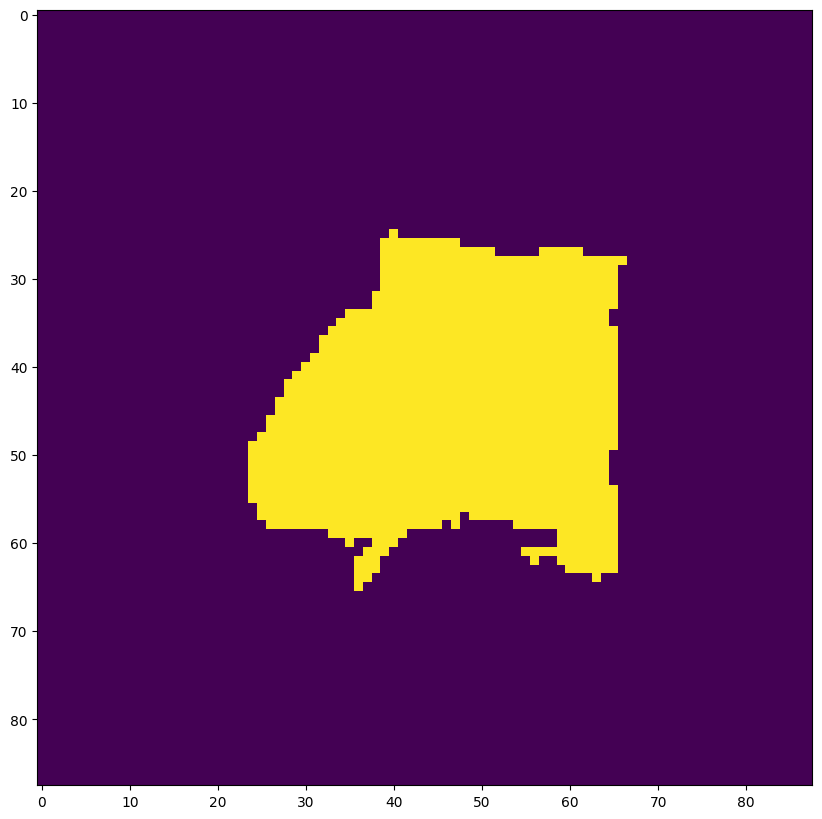

In [13]:
sampleoutput_h_file_path = '/home/cyril/git/ai8x/ai8x-synthesis/synthed_net/minimalsam/sampleoutput.h'

sampleoutput_h_dict = parse_sampleoutput.parse_sampleoutput_to_dictionary(sampleoutput_h_file_path)
print(sampleoutput_h_dict.__len__())

for key,values in sampleoutput_h_dict.items():
    print(key, len(values))

print(sampleoutput_h_dict.keys())
print(sampleoutput_h_dict["0x50400000"])

sampleoutput_h_list = sampleoutput_h_dict["0x50400000"]

print(sampleoutput_h_list[0])

pred_mask_KAT = np.zeros(shape=(7744))

for i, sampleoutput_h_word in enumerate(sampleoutput_h_list):
    sampleoutput_h_values = parse_sampleoutput.process_four_channel_data_from_word(sampleoutput_h_word)
    if (i == 0):
        print(sampleoutput_h_values[0], sampleoutput_h_values[1])
    if sampleoutput_h_values[0] >= sampleoutput_h_values[1]:
        pred_mask_KAT[i] = 0
    else:
        pred_mask_KAT[i] = 1

print(pred_mask_KAT)
print(len(pred_mask_KAT))

pred_mask_KAT = pred_mask_KAT.reshape((88, 88))

plt.figure(figsize=(10, 24))
plt.imshow(pred_mask_KAT)